In [1]:
# Install OpenCV if you don't have it already
!pip install opencv-python matplotlib

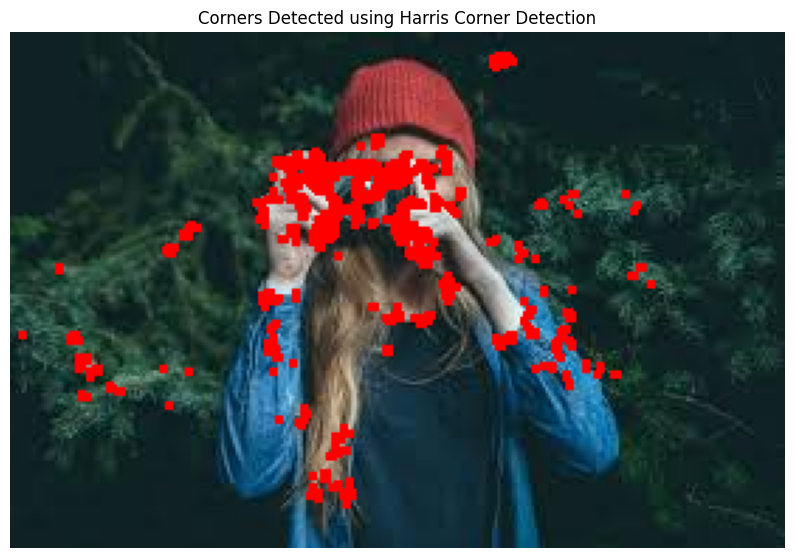

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load the image
# Replace 'input_image.jpg' with the path to your image file
image_path = 'image 2.jpg'
try:
    img = cv2.imread(image_path)

    if img is None:
        raise FileNotFoundError(f"Error: Image not found at {image_path}. Please upload an image file.")

    # Convert the image to grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Convert to float32 for Harris Corner Detector
    gray = np.float32(gray)

    # Apply Harris Corner Detector
    # Parameters:
    #   - blockSize: It is the size of neighbourhoud considered for corner detection
    #   - ksize: Aperture parameter of Sobel derivative used.
    #   - k: Harris detector free parameter in the equation.
    dst = cv2.cornerHarris(gray, blockSize=2, ksize=3, k=0.04)

    # Result is dilated for marking the corners
    dst = cv2.dilate(dst, None)

    # Threshold for an optimal value, it may vary depending on the image.
    img[dst > 0.01 * dst.max()] = [0, 0, 255] # Mark corners in red

    # Display the result
    plt.figure(figsize=(10, 8))
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title('Corners Detected using Harris Corner Detection')
    plt.axis('off')
    plt.show()

except FileNotFoundError as e:
    print(e)
    print("Please upload an image file (e.g., 'input_image.jpg') to your Colab environment or provide the correct path.")
except Exception as e:
    print(f"An error occurred: {e}")